# 08 – Random Forest Model Development

This notebook develops and evaluates baseline and hyperparameter-tuned Random Forest models for predicting Low, Medium and High waterborne disease risk.

In [1]:
# Import the libraries required for Random Forest model development

from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

In [2]:
# Define the locations of the prepared datasets, model files, and result files

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the prepared training and testing datasets

X_train = pd.read_csv(
    DATA_PATH / "X_train.csv"
)

X_test = pd.read_csv(
    DATA_PATH / "X_test.csv"
)

y_train = pd.read_csv(
    DATA_PATH / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 38)
X_test shape: (600, 38)
y_train shape: (2400,)
y_test shape: (600,)


In [4]:
# Verify the class distribution of the target variable

print("Training Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Class Distribution
risk_level
Low       807
High      799
Medium    794
Name: count, dtype: int64

Testing Class Distribution
risk_level
Low       202
High      200
Medium    198
Name: count, dtype: int64


In [5]:
# Create the baseline Random Forest model

baseline_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

print("Baseline Random Forest model created successfully.")

Baseline Random Forest model created successfully.


In [6]:
# Train the baseline Random Forest model and record the training time

start_time = time.time()

baseline_forest.fit(
    X_train,
    y_train
)

baseline_training_time = time.time() - start_time

print(f"Training completed in {baseline_training_time:.4f} seconds.")

Training completed in 0.1466 seconds.


In [7]:
# Generate predictions using the trained baseline Random Forest model

baseline_train_predictions = baseline_forest.predict(
    X_train
)

baseline_test_predictions = baseline_forest.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [8]:
# Calculate the evaluation metrics for the baseline Random Forest model

train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

precision = precision_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

generalisation_gap = train_accuracy - test_accuracy

In [9]:
# Display the evaluation results of the baseline Random Forest model

print("=" * 50)
print("Baseline Random Forest Performance")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Training Time (s) : {baseline_training_time:.4f}")
print(f"Generalisation Gap: {generalisation_gap:.4f}")

Baseline Random Forest Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.8550
Precision         : 0.8575
Recall            : 0.8550
F1-Score          : 0.8559
Training Time (s) : 0.1466
Generalisation Gap: 0.1450


In [10]:
# Display the classification report for the baseline Random Forest model

print("=" * 50)
print("Baseline Random Forest Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        baseline_test_predictions,
        digits=4,
        zero_division=0
    )
)

Baseline Random Forest Classification Report
              precision    recall  f1-score   support

        High     0.8762    0.8850    0.8806       200
         Low     0.9267    0.8762    0.9008       202
      Medium     0.7681    0.8030    0.7852       198

    accuracy                         0.8550       600
   macro avg     0.8570    0.8548    0.8555       600
weighted avg     0.8575    0.8550    0.8559       600



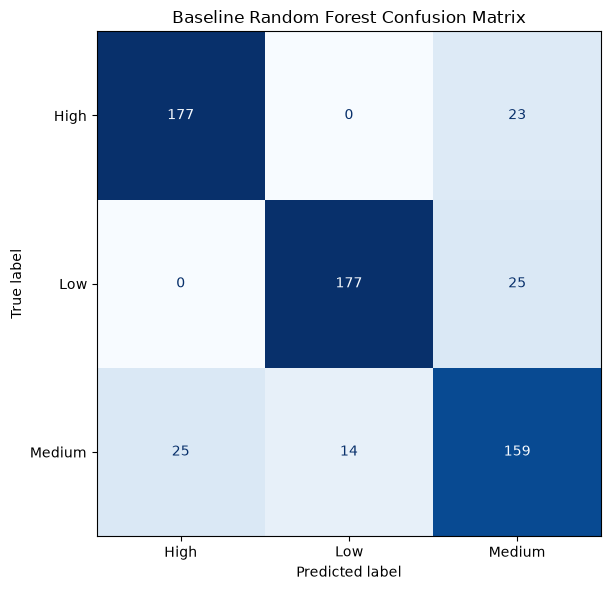

In [11]:
# Display the confusion matrix for the baseline Random Forest model

baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=baseline_forest.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Baseline Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
# Define the hyperparameter values to be tested using GridSearchCV

parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

print("Parameter grid created successfully.")

Parameter grid created successfully.


In [13]:
# Create the GridSearchCV object for Random Forest hyperparameter tuning

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [14]:
# Perform hyperparameter tuning using GridSearchCV

start_time = time.time()

grid_search.fit(
    X_train,
    y_train
)

tuning_time = time.time() - start_time

print(f"GridSearchCV completed in {tuning_time:.2f} seconds.")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
GridSearchCV completed in 76.31 seconds.


In [15]:
# Display the best hyperparameters identified by GridSearchCV

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross Validation Score:
0.8746


In [16]:
# Retrieve the best Random Forest model from GridSearchCV

tuned_forest = grid_search.best_estimator_

print("Tuned Random Forest model created successfully.")

Tuned Random Forest model created successfully.


In [17]:
# Generate predictions using the tuned Random Forest model

tuned_train_predictions = tuned_forest.predict(
    X_train
)

tuned_test_predictions = tuned_forest.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
# Calculate the evaluation metrics for the tuned Random Forest model

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_generalisation_gap = (
    tuned_train_accuracy -
    tuned_test_accuracy
)

In [19]:
# Display the evaluation results of the tuned Random Forest model

print("=" * 50)
print("Tuned Random Forest Performance")
print("=" * 50)

print(f"Training Accuracy : {tuned_train_accuracy:.4f}")
print(f"Testing Accuracy  : {tuned_test_accuracy:.4f}")
print(f"Precision         : {tuned_precision:.4f}")
print(f"Recall            : {tuned_recall:.4f}")
print(f"F1-Score          : {tuned_f1:.4f}")
print(f"Training Time (s) : {tuning_time:.4f}")
print(f"Generalisation Gap: {tuned_generalisation_gap:.4f}")

Tuned Random Forest Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.8550
Precision         : 0.8572
Recall            : 0.8550
F1-Score          : 0.8558
Training Time (s) : 76.3081
Generalisation Gap: 0.1450


In [20]:
# Display the classification report for the tuned Random Forest model

print("=" * 50)
print("Tuned Random Forest Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        tuned_test_predictions,
        digits=4,
        zero_division=0
    )
)

Tuned Random Forest Classification Report
              precision    recall  f1-score   support

        High     0.8850    0.8850    0.8850       200
         Low     0.9171    0.8762    0.8962       202
      Medium     0.7681    0.8030    0.7852       198

    accuracy                         0.8550       600
   macro avg     0.8567    0.8548    0.8555       600
weighted avg     0.8572    0.8550    0.8558       600



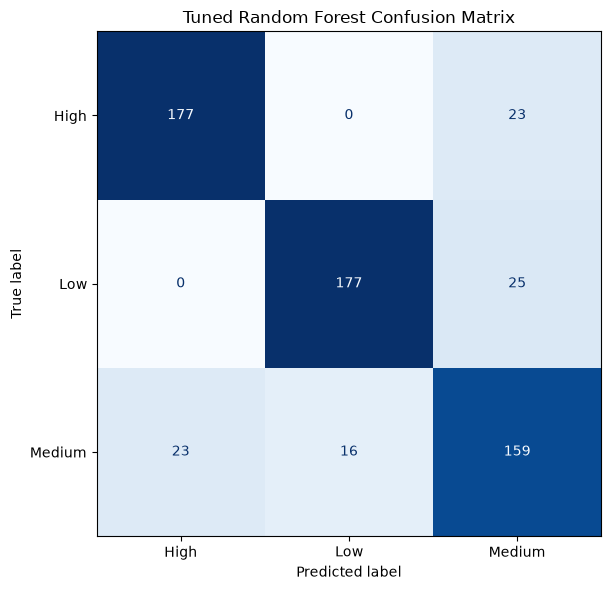

In [21]:
# Display the confusion matrix for the tuned Random Forest model

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=tuned_forest.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Compare the baseline and tuned Random Forest models

comparison_results = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Training Accuracy": [
        train_accuracy,
        tuned_train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy,
        tuned_test_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ],
    "Generalisation Gap": [
        generalisation_gap,
        tuned_generalisation_gap
    ]
})

comparison_results = comparison_results.round(4)

comparison_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
0,Baseline Random Forest,1.0,0.855,0.8575,0.855,0.8559,0.145
1,Tuned Random Forest,1.0,0.855,0.8572,0.855,0.8558,0.145


In [23]:
# Select the better Random Forest model based on the F1-Score

if tuned_f1 >= f1:
    final_forest_model = tuned_forest
    selected_model = "Tuned Random Forest"
else:
    final_forest_model = baseline_forest
    selected_model = "Baseline Random Forest"

print("=" * 60)
print("Final Random Forest Model Selection")
print("=" * 60)
print(f"Selected Model : {selected_model}")

if selected_model == "Tuned Random Forest":
    print(f"Testing Accuracy : {tuned_test_accuracy:.4f}")
    print(f"F1-Score         : {tuned_f1:.4f}")
else:
    print(f"Testing Accuracy : {test_accuracy:.4f}")
    print(f"F1-Score         : {f1:.4f}")

print("\nReason:")
print("The tuned model achieved performance equal to the baseline while using hyperparameters selected through GridSearchCV.")

Final Random Forest Model Selection
Selected Model : Baseline Random Forest
Testing Accuracy : 0.8550
F1-Score         : 0.8559

Reason:
The tuned model achieved performance equal to the baseline while using hyperparameters selected through GridSearchCV.


In [24]:
# Save the baseline and tuned Random Forest models

joblib.dump(
    baseline_forest,
    MODEL_PATH / "random_forest_baseline.pkl"
)

joblib.dump(
    tuned_forest,
    MODEL_PATH / "random_forest_tuned.pkl"
)

print("Random Forest models saved successfully.")

Random Forest models saved successfully.


In [25]:
# Save the Random Forest comparison results

comparison_results.to_csv(
    RESULTS_PATH / "random_forest_results.csv",
    index=False
)

print("Random Forest comparison results saved successfully.")

Random Forest comparison results saved successfully.


In [26]:
# Save the Random Forest GridSearchCV results

grid_search_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_results.to_csv(
    RESULTS_PATH / "random_forest_grid_search_results.csv",
    index=False
)

print("Random Forest GridSearchCV results saved successfully.")

Random Forest GridSearchCV results saved successfully.


In [27]:
# Save the best Random Forest hyperparameters

joblib.dump(
    grid_search.best_params_,
    RESULTS_PATH / "random_forest_best_parameters.pkl"
)

print("Random Forest best parameters saved successfully.")

Random Forest best parameters saved successfully.


In [28]:
# Verify that all Random Forest files were created

files_to_check = [
    MODEL_PATH / "random_forest_baseline.pkl",
    MODEL_PATH / "random_forest_tuned.pkl",
    RESULTS_PATH / "random_forest_results.csv",
    RESULTS_PATH / "random_forest_grid_search_results.csv",
    RESULTS_PATH / "random_forest_best_parameters.pkl"
]

for file in files_to_check:
    print(f"{file.name:<55} {file.exists()}")

random_forest_baseline.pkl                              True
random_forest_tuned.pkl                                 True
random_forest_results.csv                               True
random_forest_grid_search_results.csv                   True
random_forest_best_parameters.pkl                       True
